## **SAVE A COPY OF THIS NOTEBOOK TO PUT ANSWERS INTO**

# Part 1 (Reading Assignment), 20 points

**Reminder: there are 5 reading assignments, 3% each for 15% total of your final grade.**

The reading assignment consists of two papers - [one on alignment before fusion](https://arxiv.org/abs/2107.07651), and one on the [Platonic Representation Hypothesis](https://arxiv.org/pdf/2405.07987). Read both papers and then answer the following questions:

1. Explain the implications of 'align before fuse' on your tasks of interest. at which degree, and what type of fusion needs to be performed? And what level of alignment would you need to perform for your data, so that subsequent fusion or representation learning is successful?
2. How can you perform controlled experiments to validate the types of fusion and/or alignment needed for your tasks? What are some challenges you foresee in fusing and aligning your data?
3. Explain the implications of 'platonic representation hypothesis' on your tasks of interest. Do you believe alignment between modalities would automatically emerge as models trained on your data are scaled up?
4. What are some reasons why alignment would not emerge i.e., counter-arguments to the platonic representation hypothesis? You are encouraged to search for follow-up works to the original paper that both support and counter the original arguments.
5. What experiments would you propose to validate the existence and emergence of alignment in your tasks?
6. Can you also think of some downsides of strongly (or perfectly) aligning your data modalities? How can you design experiments to validate that these risks are not present in your trained models?

#Part 2 (Homework Assignment), 100 points

**Reminder: there are 5 homework assignments, 7% each for 35% total of your final grade.**

For this assignment, we will finally begin playing with some of the concepts discussed in the class regarding multimodal modeling.

The first part will deal with Einsum and Tensors.

# Problem 1: Tensors (5 points)

(5 pts) Let's start with tensors. A tensor represents an N-th dimensional array of numbers. In machine learning, they are used to represent data as they can efficiently represent complex data to train with. We traditionally use PyTorch as the package of choice to work with tensors. Fill in the code below with the right tensor operations. Feel free to consult the documentation and the PyTorch tutorials for help.

In [1]:
import torch
mat_A = torch.rand(3, 2)
mat_B = torch.rand(2, 3)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py", line 37, in <module>
    ColabKernelApp.launch_instance()
  File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelapp.py", line 712, in start
    self.io_loop.start()
  File "/usr/local/lib/python3.12/dist-package

In [2]:
# Common PyTorch operations

# Adding
mat_C = mat_A + mat_A

# Transpose
mat_A_transpose = mat_A.T

# Matrix multiplication
mat_mult  = mat_A @ mat_B

# Element-wise multiplication
mat_mult_elm = mat_A * mat_A

# Create a tensor of size (4, 4) of ones
ones = torch.ones(4, 4)

# Compute mean of A
mean_A = mat_A.mean()

# Problem 2: Einsum (5 points)

(10 pts)
Now lets proceed with Einsum. This is a powerful, compact notation used for expressing complex tensor operations on multi-dimensional arrays using a simple string of index labels.

Here is a quick example of using einsum to multiply two matrices.

In [3]:
A = torch.rand(3, 2)
B = torch.rand(2, 3)

C = torch.einsum('ij,jk->ik', A, B)
print(C)

tensor([[0.3811, 0.2162, 0.4167],
        [0.5050, 0.2557, 0.5830],
        [0.9587, 0.5015, 1.0909]])


The labels provide a shorthand as to what operation to do. Think of the left index as what is before, and the right as to what the dimensions of the final product should look like.

Now use this to do the other possible operations:

In [4]:
a = torch.rand(3, 1)
b = torch.rand(3, 1)

A = torch.rand(3, 2)
B = torch.rand(2, 3)

# Dot Product of a and b
d_prod = torch.einsum('ij,ij->', a, b)

# Transpose using vector b
transpose = torch.einsum('ij->ji', b)

# Summation (element-wise and column-wise of A)
sum_element = torch.einsum('ij->', A)
sum_column = torch.einsum('ij->j', A)

# Diagonal of A
A_sq = torch.rand(3, 3)
diag = torch.einsum('ii->i', A_sq)

# Outer Product of A and B
outer = torch.einsum('ik,jl->ij', a, b)

# Problem 3: Unimodal Models (10 points)

We now explore unimodal models and multimodal fusion. For the first part we will work on the image and audio digit dataset AV-MNIST to do digit classification. To benchmark effectiveness, we will use the [Multibench](https://arxiv.org/abs/2107.07502) benchmark. First, we will clone the repo, and get the necessary packages and dataset.

**Note: MAKE SURE YOU SWITCH TO A GPU TO RUN THE MODELS. RUNTIME -> CHANGE RUNTIME TYPE -> T4 GPU (or any other). Be mindful of Google's GPU limits based on what kind of account you own.**

**Also, if you are a student you should be able to have Colab Pro for free if you don't already. Take advantage of that!**

**THIS IS AN EXAMPLE, DO NOT BE RESTRICTED BY WHAT WE DO HERE WHEN YOU HAVE TO IMPLEMENT THIS FOR YOUR OWN DATASET.**

In [5]:
# 1. Clear out conflicting audio/vision packages
!pip uninstall -y torch torchvision torchtext torchaudio 2>/dev/null || true

# 2. Pin NumPy <2 to avoid the PyTorch ABI break
!pip install -q "numpy<2"

# 3. Install a matching PyTorch stack (without dependencies to prevent overriding numpy)
!pip install -q torch==2.2.2 torchvision==0.17.2 torchtext==0.17.2 torchaudio==2.2.2 --no-deps

# 4. Force reinstall the data stack so it links against the older numpy
!pip install -q --force-reinstall pandas scipy scikit-learn

# 5. Install all required utilities and CLIP in one go
!pip install -q gdown memory_profiler ftfy regex tqdm transformers
!pip install -q git+https://github.com/openai/CLIP.git

print("✅ Installations complete. RESTART YOUR RUNTIME NOW (Runtime -> Restart session) before proceeding.")

Found existing installation: torch 2.2.2
Uninstalling torch-2.2.2:
  Successfully uninstalled torch-2.2.2
Found existing installation: torchvision 0.17.2
Uninstalling torchvision-0.17.2:
  Successfully uninstalled torchvision-0.17.2
Found existing installation: torchtext 0.17.2
Uninstalling torchtext-0.17.2:
  Successfully uninstalled torchtext-0.17.2
Found existing installation: torchaudio 2.2.2
Uninstalling torchaudio-2.2.2:
  Successfully uninstalled torchaudio-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
accelerate 1.12.0 requires torch>=2.0.0, which is not installed.
peft 0.18.1 requires torch>=1.13.0, which is not installed.
sentence-transformers 5.2.3 requires torch>=1.11.0, which is not installed.
fastai 2.8.7 requires torch<3,>=1.10, which is not installed.
fastai 2.8.7 requires torchvision>=0.11, which is not installed.
google-colab 1.0.0 req

# Getting repo

In [6]:
# --- Standard Library ---
import os
import sys
import json
import time

# --- Data & Visualization ---
import numpy as np
import pandas as pd
import sklearn.metrics
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# --- PyTorch Stack ---
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torch.cuda.amp import autocast, GradScaler
from torch.autograd import Variable

# --- Third-Party & Models ---
from tqdm import tqdm
import clip

# Set up global device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Imports loaded. Using device: {device}")

✅ Imports loaded. Using device: cuda


In [7]:
!git clone https://github.com/pliang279/MultiBench.git
%cd MultiBench

Cloning into 'MultiBench'...
remote: Enumerating objects: 6943, done.
remote: Counting objects: 100% (402/402), done.
remote: Compressing objects: 100% (61/61), done.
remote: Total 6943 (delta 363), reused 341 (delta 341), pack-reused 6541 (from 1)
Receiving objects: 100% (6943/6943), 51.03 MiB | 22.52 MiB/s, done.
Resolving deltas: 100% (4281/4281), done.
/content/MultiBench


In [8]:
# --- MultiBench setup (run after !git clone ... and %cd MultiBench) ---
from datasets.avmnist.get_data import get_dataloader
from unimodals.common_models import GRU, MLP, Sequential, Identity
from fusions.common_fusions import MultiplicativeInteractions2Modal, Concat
from training_structures.Supervised_Learning import train, test

# Patch accuracy to bypass tensor.numpy() "Numpy is not available" (numpy<2 / Colab)
import eval_scripts.performance as _perf

def _accuracy_fixed(truth, pred):
    t = truth.cpu().tolist() if hasattr(truth, 'cpu') else truth
    p = pred.cpu().tolist() if hasattr(pred, 'cpu') else pred
    return sklearn.metrics.accuracy_score(np.array(t), np.array(p))

_perf.accuracy = _accuracy_fixed
_sl = sys.modules.get('training_structures.Supervised_Learning')
if _sl is not None:
    _sl.accuracy = _accuracy_fixed

print("✅ MultiBench loaded (get_dataloader, train, test, fusion helpers).")

✅ MultiBench loaded (get_dataloader, train, test, fusion helpers).


**Note:** If you see pip "dependency conflict" messages (e.g. peft/accelerate want torch, or other packages want numpy≥2), you can ignore them for this notebook. We install torch 2.2.2 and numpy<2 on purpose. After the install cell finishes, **restart the runtime once** (Runtime → Restart session), then run from the top.

# Getting AV-MNIST dataset

In [9]:
!mkdir -p av-mnist
!gdown 1KvKynJJca5tDtI5Mmp6CoRh9pQywH8Xp

Downloading...
From (original): https://drive.google.com/uc?id=1KvKynJJca5tDtI5Mmp6CoRh9pQywH8Xp
From (redirected): https://drive.google.com/uc?id=1KvKynJJca5tDtI5Mmp6CoRh9pQywH8Xp&confirm=t&uuid=49631f4e-7d1f-46d8-a1a5-ecc707bed30b
To: /content/MultiBench/avmnist.tar.gz
100% 1.60G/1.60G [00:11<00:00, 143MB/s] 


In [10]:
!tar -xvzf avmnist.tar.gz -C av-mnist

avmnist/
avmnist/test_labels.npy
avmnist/image/
avmnist/image/train_data.npy
avmnist/image/test_data.npy
avmnist/audio/
avmnist/audio/train_data.npy
avmnist/audio/test_data.npy
avmnist/train_labels.npy
avmnist/avmnist_temp/
avmnist/avmnist_temp/train_labels.npy
avmnist/avmnist_temp/image/
avmnist/avmnist_temp/image/test_data.npy
avmnist/avmnist_temp/image/train_data.npy
avmnist/avmnist_temp/test_labels.npy


In [11]:
# 1. Path to the folder you untarred
data_dir = 'av-mnist/avmnist'

from datasets.avmnist.get_data import get_dataloader
from torch.utils.data import DataLoader

traindata, validdata, testdata = get_dataloader(data_dir, batch_size=256)

# Fix: default collate fails on numpy.int64 labels in some PyTorch/numpy versions.
def _avmnist_collate(batch):
    from torch.utils.data.dataloader import default_collate
    imgs = default_collate([b[0] for b in batch])
    audios = default_collate([b[1] for b in batch])
    labels = torch.tensor([int(b[2]) for b in batch], dtype=torch.long)
    return (imgs, audios, labels)

train_dataset, valid_dataset, test_dataset = traindata.dataset, validdata.dataset, testdata.dataset
bs = traindata.batch_size
traindata = DataLoader(train_dataset, batch_size=bs, shuffle=True, num_workers=traindata.num_workers, collate_fn=_avmnist_collate)
validdata = DataLoader(valid_dataset, batch_size=bs, shuffle=False, num_workers=validdata.num_workers, collate_fn=_avmnist_collate)
testdata = DataLoader(test_dataset, batch_size=bs, shuffle=False, num_workers=testdata.num_workers, collate_fn=_avmnist_collate)

# Getting packages

We will now start by creating, training, and testing unimodal models for each of the AV-MNIST modalities.

# Audio

In [12]:
class AudioModel(nn.Module):
    def __init__(self, input_dim=12544, hidden_dim=64, dropout_probability=0.2):
        super(AudioModel, self).__init__()
        self.conv = nn.Sequential(
            # Start with a stride of 2 to instantly cut data in half
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1), # 112 -> 56
            nn.ReLU(),
            nn.MaxPool2d(2),                                     # 56 -> 28
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), # 28 -> 14
            nn.ReLU(),
            nn.Flatten() # Only 6272 features now!
        )
        self.dropout = nn.Dropout(dropout_probability)
        self.fc = nn.Linear(6272, 10)

    def forward(self, x):
        x = x.view(-1, 1, 112, 112)
        x = self.conv(x)
        x = self.dropout(x)
        return self.fc(x)

# Image

In [13]:
class ImageModel(nn.Module):
    def __init__(self, dropout_prob=0.2):
        super(ImageModel, self).__init__()
        self.dropout_prob = dropout_prob  # easily configurable during initialization

        # input: [batch, 1, 28, 28]
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2) # Reduces size by half

        # After two poolings: 28 -> 14 -> 7
        # Final flattened size: 64 channels * 7 * 7
        self.fc = nn.Sequential(
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(self.dropout_prob),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        # Flatten all dimensions except batch
        x = torch.flatten(x, 1)
        return self.fc(x)

# Training and Testing

We use cross-entropy due to this being a classification task

In [14]:
# We use a scalar here to reduce system RAM use (to avoid crashing the session) while not impacting performance.
scaler = GradScaler()

def train_and_test_unimodal(model, train_loader, valid_loader, test_loader, modality_idx, epochs=5, lr=1e-3, weight_decay=1e-3):
    device = torch.device("cuda")
    model.to(device)

    # Use CrossEntropyLoss for a classification task
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_valid_loss = float('inf')

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for batch in train_loader:
            # batch[0] = images, batch[1] = audio
            x = batch[modality_idx].to(device).float()

            # Classification labels must be Long tensors, not Float
            y = batch[2].to(device).long().squeeze()

            optimizer.zero_grad()

            with autocast():
                outputs = model(x)
                loss = criterion(outputs, y)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            train_loss += loss.item()

        # --- Validation Phase ---
        model.eval()
        valid_loss = 0
        correct = 0
        total = 0
        with torch.no_grad():
            for batch in valid_loader:
                x = batch[modality_idx].to(device).float()
                y = batch[2].to(device).long().squeeze()

                outputs = model(x)
                valid_loss += criterion(outputs, y).item()

                _, predicted = torch.max(outputs.data, 1)
                total += y.size(0)
                correct += (predicted == y).sum().item()

        avg_train = train_loss / len(train_loader)
        avg_valid = valid_loss / len(valid_loader)
        accuracy = 100 * correct / total

        if avg_valid < best_valid_loss:
            best_valid_loss = avg_valid
            torch.save(model.state_dict(), 'best_avmnist_model.pt')

        print(f"Epoch {epoch}: Train Loss: {avg_train:.4f} | Valid Acc: {accuracy:.2f}%")

    # Final Testing follows the same logic (CrossEntropy + Index 2)
    print("\n--- Final Evaluation Complete ---")
    model.load_state_dict(torch.load('best_avmnist_model.pt'))
    model.eval()
    test_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in test_loader:
            x = batch[modality_idx].to(device).float()
            y = batch[2].to(device).long().squeeze()

            outputs = model(x)
            test_loss += criterion(outputs, y).item()

            _, predicted = torch.max(outputs.data, 1)
            total += y.size(0)
            correct += (predicted == y).sum().item()

        test_accuracy = 100 * correct / total
        test_loss /= len(test_loader)
        print(f"Final Test Loss: {test_loss:.4f} | Test Accuracy: {test_accuracy:.2f}%")
    return test_accuracy

# Training and testing for each modality:

# Audio:

In [15]:
learning_rates = [1e-3, 5e-4]
dropouts = [0.2, 0.4]
weight_decays = [1e-3, 1e-4]
best_test_accuracy = -1.0
best_lr = None
best_dropout = None
best_weight_decay = None

for lr in learning_rates:
    for dropout in dropouts:
        for wd in weight_decays:
            model = AudioModel(dropout_probability=dropout)
            test_accuracy = train_and_test_unimodal(
                model, traindata, validdata, testdata,
                modality_idx=1, lr=lr, weight_decay=wd
            )
            if test_accuracy > best_test_accuracy:
                best_test_accuracy = test_accuracy
                best_lr = lr
                best_dropout = dropout
                best_weight_decay = wd

print("\n" + "=" * 50)
print("AUDIO MODALITY – HYPERPARAMETER SEARCH SUMMARY")
print("=" * 50)
print(f"Best test accuracy: {best_test_accuracy:.2f}%")
print(f"Best learning rate: {best_lr}")
print(f"Best dropout:       {best_dropout}")
print(f"Best weight_decay:  {best_weight_decay}")
print("=" * 50)

Epoch 0: Train Loss: 2.1319 | Valid Acc: 37.48%
Epoch 1: Train Loss: 2.0387 | Valid Acc: 38.62%
Epoch 2: Train Loss: 2.0132 | Valid Acc: 39.80%
Epoch 3: Train Loss: 1.9983 | Valid Acc: 40.08%
Epoch 4: Train Loss: 1.9891 | Valid Acc: 40.58%

--- Final Evaluation Complete ---
Final Test Loss: 2.0213 | Test Accuracy: 40.33%
Epoch 0: Train Loss: 2.1147 | Valid Acc: 38.40%
Epoch 1: Train Loss: 2.0203 | Valid Acc: 39.98%
Epoch 2: Train Loss: 1.9991 | Valid Acc: 40.58%
Epoch 3: Train Loss: 1.9846 | Valid Acc: 40.84%
Epoch 4: Train Loss: 1.9756 | Valid Acc: 41.18%

--- Final Evaluation Complete ---
Final Test Loss: 2.0201 | Test Accuracy: 40.72%
Epoch 0: Train Loss: 2.1035 | Valid Acc: 37.80%
Epoch 1: Train Loss: 2.0238 | Valid Acc: 39.36%
Epoch 2: Train Loss: 2.0027 | Valid Acc: 40.34%
Epoch 3: Train Loss: 1.9925 | Valid Acc: 40.80%
Epoch 4: Train Loss: 1.9844 | Valid Acc: 40.98%

--- Final Evaluation Complete ---
Final Test Loss: 2.0117 | Test Accuracy: 40.79%
Epoch 0: Train Loss: 2.1129 | V

# Image:

In [16]:
learning_rates = [1e-3, 5e-4, 1e-4]
dropouts = [0.1, 0.3, 0.5]
best_test_accuracy = -1.0
best_lr = None
best_dropout = None

for lr in learning_rates:
    for dropout in dropouts:
        model = ImageModel(dropout_prob=dropout)
        test_accuracy = train_and_test_unimodal(
            model, traindata, validdata, testdata, modality_idx=0, lr=lr
        )
        if test_accuracy > best_test_accuracy:
            best_test_accuracy = test_accuracy
            best_lr = lr
            best_dropout = dropout

print("\n" + "=" * 50)
print("IMAGE MODALITY – HYPERPARAMETER SEARCH SUMMARY")
print("=" * 50)
print(f"Best test accuracy: {best_test_accuracy:.2f}%")
print(f"Best learning rate: {best_lr}")
print(f"Best dropout:       {best_dropout}")
print("=" * 50)

Epoch 0: Train Loss: 1.1146 | Valid Acc: 66.44%
Epoch 1: Train Loss: 0.9345 | Valid Acc: 66.20%
Epoch 2: Train Loss: 0.9141 | Valid Acc: 67.94%
Epoch 3: Train Loss: 0.9042 | Valid Acc: 68.38%
Epoch 4: Train Loss: 0.8982 | Valid Acc: 68.24%

--- Final Evaluation Complete ---
Final Test Loss: 0.9059 | Test Accuracy: 64.06%
Epoch 0: Train Loss: 1.1236 | Valid Acc: 66.92%
Epoch 1: Train Loss: 0.9597 | Valid Acc: 67.88%
Epoch 2: Train Loss: 0.9393 | Valid Acc: 68.08%
Epoch 3: Train Loss: 0.9297 | Valid Acc: 68.22%
Epoch 4: Train Loss: 0.9250 | Valid Acc: 69.02%

--- Final Evaluation Complete ---
Final Test Loss: 0.9090 | Test Accuracy: 63.84%
Epoch 0: Train Loss: 1.1882 | Valid Acc: 66.70%
Epoch 1: Train Loss: 0.9938 | Valid Acc: 67.50%
Epoch 2: Train Loss: 0.9734 | Valid Acc: 67.58%
Epoch 3: Train Loss: 0.9603 | Valid Acc: 67.56%
Epoch 4: Train Loss: 0.9556 | Valid Acc: 68.84%

--- Final Evaluation Complete ---
Final Test Loss: 0.9067 | Test Accuracy: 63.83%
Epoch 0: Train Loss: 1.1919 | V

Answer the following questions:

1. (5 points) Try to get the best performance out of each model by playing around with hyperparameters (hint: you may have to playing around and even add additional arguments to the layers like dropout, look at the documentation and look into how we can improve performace). List the best performance you were able to get and the hyperparameters you used.
2. (5 points) Compare the performances of each modality. What do these suggest to you? What could be done to get the worst performing ones to get closer to the best performing modality/model?

# Problem 4: Multimodal Fusion (10 points)

Now you will play with multimodal fusion. Lets use a late fusion to improve our performance. We have provided some code with the hyperparameters to consider, but you are encouraged to play with them to try to get improvments. To make things simpler, the encoders for both modalities have been provided. However, some other parts are missing, so you will have to fill those in!

In [17]:
# Image Encoder
class ImageEncoder(nn.Module):
    def __init__(self, output_dim=64):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, output_dim)
        )
    def forward(self, x):
        return self.conv(x)

# Audio Encoder
class AudioEncoder(nn.Module):
    def __init__(self, output_dim=64):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1), nn.BatchNorm2d(32), nn.ReLU(), # 112 -> 56
            nn.MaxPool2d(2), # 56 -> 28
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.BatchNorm2d(64), nn.ReLU(), # 28 -> 14
            nn.Flatten(),
            nn.Linear(64 * 14 * 14, output_dim)
        )
    def forward(self, x):
        return self.conv(x)

# TODO: Encoders - create the list of encoders, images should be first, then audio
encoders = [ImageEncoder(), AudioEncoder()]

# TODO: Use the concat fusion as the fusion of choice
fusion = Concat()

# TODO: Create the head, which learns the joint features.
# This should be an MLP that takes with input size based
# on output size of your concationation, a hidden layer of size 256, and output layer
# of size 10.

head = nn.Sequential(nn.Linear(64 + 64, 256), nn.ReLU(), nn.Linear(256, 10))

# Run Training
print("Starting Training...")
train(encoders, fusion, head, traindata, validdata, 5,
      task="classification", optimtype=torch.optim.AdamW, is_packed=False,
      lr=5e-4, save='avmnist_lmf.pt', weight_decay=0.001,
      objective=torch.nn.CrossEntropyLoss(), track_complexity=False)

# Run Test
model = torch.load('avmnist_lmf.pt').cuda()
test(model, testdata, 'avmnist', is_packed=False, task="classification",
      criterion=torch.nn.CrossEntropyLoss(), no_robust=True)

Starting Training...
Epoch 0 train loss: tensor(0.9039, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 0 valid loss: tensor(0.7443, device='cuda:0') acc: 0.7256
Saving Best
Epoch 1 train loss: tensor(0.7572, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 1 valid loss: tensor(0.7180, device='cuda:0') acc: 0.7344
Saving Best
Epoch 2 train loss: tensor(0.7178, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 2 valid loss: tensor(0.7306, device='cuda:0') acc: 0.7296
Epoch 3 train loss: tensor(0.6840, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 3 valid loss: tensor(0.7480, device='cuda:0') acc: 0.7282
Epoch 4 train loss: tensor(0.6536, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 4 valid loss: tensor(0.7364, device='cuda:0') acc: 0.7298
acc: 0.7059
Inference Time: 8.294352769851685
Inference Params: 1077258


Answer the following:
1. (2 points) Sometimes when training you may notice the model gets stuck in a range of loss and never seems to get it's loss down. What does this suggest? What are some ways you can fix this?
2. (2 points) What are some other fusion methods we could use that we could use? Would they lead to improvements compared to early fusion?
3. (6 points) Explain the difference between early fusion techniques and late fusion techniques. Be sure to discuss their benefits and tradeoffs.

# Problem 5: Other Fusion Techniques (30 points)

Now, we want you to try implementing some of these fusion techniques on your dataset! For this part, you will implement these fusion techniques:
1. Early fusion
2. Late fusion
3. TensorFusion
4. Low-Rank Tensor (LMF) Fusion


**You cannot just import and use the functions available in Multibench to do this. In addition, use einsum where applicable. TO RECIEVE FULL CREDIT, THE FUSIONS YOU IMPLEMENTATION MUST WORK WITH THE DATASET YOU CREATED FROM HOMEWORK 1. YOU WILL HAVE TO CREATE A SIMPLE MODEL FOR EACH FUSION TECHNIQUE TO PLAY WITH.**

**(5 points)** In your write up, report the best validation accuracies of your multimodal model (don't forget to include what hyperparameters you included) after training and any modifications that had to be done to your data or model to be able to train on it. In addition, talk about which technique you believe would be best for your dataset and why that is.

**Design the fusion classes with the modalities you are specifically working with in mind. The example we worked through above with MOSI was meant as a showcase of fusion in action - we do not require you to use text, video and audio as the modalities. Use whichever ones you are working with!**

The code below provided is to be filled in with the models you set up for each technique. For an example, the first fusion technique has been done for you.

**Answer Here:**

# Early Fusion

In [18]:
class EarlyFusion(nn.Module):
  def __init__(self, input_dim1, input_dim2, output_dim):
    super(EarlyFusion, self).__init__()
    self.fc = nn.Sequential(
        nn.Linear(input_dim1 + input_dim2, 128),
        nn.ReLU(),
        nn.Linear(128, output_dim)
    )

  def forward(self, x):
    # x[0] = user_query, x[1] = function_calls
    fused = torch.cat((x[0], x[1]), dim=1)
    return self.fc(fused)

# (5 Points) Late Fusion

In [19]:
class LateFusion(nn.Module):
  def __init__(self, input_dim1, input_dim2, output_dim):
    super(LateFusion, self).__init__()
    self.encoder1 = nn.Sequential(nn.Linear(input_dim1, 64), nn.ReLU())
    self.encoder2 = nn.Sequential(nn.Linear(input_dim2, 64), nn.ReLU())
    self.classifier = nn.Linear(64 + 64, output_dim)

  def forward(self, x):
    out1 = self.encoder1(x[0])
    out2 = self.encoder2(x[1])
    fused = torch.cat((out1, out2), dim=1)
    return self.classifier(fused)

# (5 points) Tensor Fusion

In [20]:
class TensorFusion(nn.Module):
  def __init__(self, input_dim1, input_dim2, output_dim):
    super(TensorFusion, self).__init__()
    self.encoder1 = nn.Linear(input_dim1, 64)
    self.encoder2 = nn.Linear(input_dim2, 64)
    self.classifier = nn.Linear(65 * 65, output_dim)

  def forward(self, x):
    out1 = self.encoder1(x[0])
    out2 = self.encoder2(x[1])
    batch_size = out1.size(0)
    out1_plus = torch.cat([out1, torch.ones(batch_size, 1).to(out1.device)], dim=1)
    out2_plus = torch.cat([out2, torch.ones(batch_size, 1).to(out2.device)], dim=1)
    outer_product = torch.einsum('bi,bj->bij', out1_plus, out2_plus)
    return self.classifier(outer_product.flatten(start_dim=1))

# (5 Points) Low-Rank Tensor Fusion (LMF) Fusion

In [21]:
class LMFFusion(nn.Module):
  def __init__(self, input_dim1, input_dim2, output_dim, rank=4):
    super(LMFFusion, self).__init__()
    self.rank = rank
    self.encoder1 = nn.Linear(input_dim1, 64)
    self.encoder2 = nn.Linear(input_dim2, 64)
    self.factor1 = nn.Parameter(torch.Tensor(self.rank, 65, output_dim))
    self.factor2 = nn.Parameter(torch.Tensor(self.rank, 65, output_dim))
    nn.init.xavier_normal_(self.factor1)
    nn.init.xavier_normal_(self.factor2)

  def forward(self, x):
    out1 = self.encoder1(x[0])
    out2 = self.encoder2(x[1])
    batch_size = out1.size(0)
    out1_plus = torch.cat([out1, torch.ones(batch_size, 1).to(out1.device)], dim=1)
    out2_plus = torch.cat([out2, torch.ones(batch_size, 1).to(out2.device)], dim=1)
    fusion1 = torch.einsum('bi,rio->bro', out1_plus, self.factor1)
    fusion2 = torch.einsum('bj,rjo->bro', out2_plus, self.factor2)
    return (fusion1 * fusion2).sum(dim=1)

In [22]:
try:
    from google.colab import drive
    drive.mount("/content/drive")
    print("Drive mounted at /content/drive")
except Exception as e:
    print("Not in Colab or mount failed:", e)

Mounted at /content/drive
Drive mounted at /content/drive


In [23]:
# From HW1: load from toolbench_data on Google Drive (mount Drive first: Runtime -> Mount drive)
import json
import os
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from torch.utils.data import TensorDataset, DataLoader
import random

class FusionDataset(torch.utils.data.Dataset):
    """Dataset of (query, api) pairs with binary labels: 1 = correct pair, 0 = incorrect pair. 2x original size, 50/50 positive/negative."""

    def __init__(self, queries, apis):
        paired_queries = []
        paired_apis = []
        binary_labels = []
        n = len(queries)
        for i in range(n):
            # Positive sample: correct pair (queries[i], apis[i])
            paired_queries.append(queries[i])
            paired_apis.append(apis[i])
            binary_labels.append(1)
            # Negative sample: incorrect pair (queries[i], apis[j]) for random j != i (skip if n==1)
            if n >= 2:
                j = random.randint(0, n - 1)
                while j == i:
                    j = random.randint(0, n - 1)
                paired_queries.append(queries[i])
                paired_apis.append(apis[j])
                binary_labels.append(0)
        self.query_data = torch.stack(paired_queries)
        self.api_data = torch.stack(paired_apis)
        self.labels = torch.tensor(binary_labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.query_data[idx], self.api_data[idx], self.labels[idx]

TRAIN_FILE = "toolllama_G123_dfs_train.json"
DATA_DIR = "/content/drive/MyDrive/Colab Notebooks/toolbench_data"
if not os.path.isfile(os.path.join(DATA_DIR, TRAIN_FILE)):
    raise FileNotFoundError(
        f"{TRAIN_FILE} not found at {DATA_DIR}. "
        "Mount Drive (Runtime -> Mount drive) and put toolbench_data in Colab Notebooks."
    )
print(f"Using ToolBench data: {DATA_DIR}")
TFIDF_MAX_FEATURES = 500
NUM_LABEL_BINS = 5

with open(os.path.join(DATA_DIR, TRAIN_FILE)) as f:
    train_data = json.load(f)

def extract_modalities(example):
    modalities = {"id": example["id"], "user_query": "", "system_prompt": "", "assistant_thoughts": [], "function_calls": [], "function_responses": []}
    for turn in example["conversations"]:
        role, value = turn["from"], turn["value"]
        if role == "system": modalities["system_prompt"] = value
        elif role == "user": modalities["user_query"] = value
        elif role == "assistant": modalities["assistant_thoughts"].append(value)
        elif role == "function": modalities["function_responses"].append(value)
    for thought in modalities["assistant_thoughts"]:
        if "Action:" in thought and "Action Input:" in thought:
            try:
                action_line = thought.split("Action:")[1].split("Action Input:")[0].strip()
                action_input = thought.split("Action Input:")[1].strip()
                modalities["function_calls"].append({"action": action_line, "input": action_input})
            except IndexError:
                pass
    return modalities

records = []
for ex in train_data[:5000]:
    m = extract_modalities(ex)
    call_strs = []
    for fc in m["function_calls"]:
        try:
            params = json.loads(fc["input"])
            param_str = ", ".join(f"{k}={v}" for k, v in params.items()) if isinstance(params, dict) else fc["input"]
        except (json.JSONDecodeError, AttributeError):
            param_str = fc["input"][:100]
        call_strs.append(f"{fc['action']} | {param_str}")
    records.append({
        "user_query": m["user_query"],
        "function_calls_text": " ;; ".join(call_strs) if call_strs else "",
        "num_function_calls": len(m["function_calls"]),
    })

df = pd.DataFrame(records)
query_texts = df["user_query"].fillna("").tolist()
api_texts = df["function_calls_text"].fillna("").tolist()

vec_query = TfidfVectorizer(max_features=TFIDF_MAX_FEATURES, stop_words="english", token_pattern=r"(?u)\b\w[\w./_-]+\b")
vec_api = TfidfVectorizer(max_features=TFIDF_MAX_FEATURES, stop_words="english", token_pattern=r"(?u)\b\w[\w./_-]+\b")
query_feats = torch.FloatTensor(vec_query.fit_transform(query_texts).toarray())
api_feats = torch.FloatTensor(vec_api.fit_transform(api_texts).toarray())

# Binary relevance: use FusionDataset for (query, api) pairs with label 1 = match, 0 = non-match (2x size, 50/50)
toolbench_ds = FusionDataset(query_feats, api_feats)
train_size = int(0.8 * len(toolbench_ds))
val_size = len(toolbench_ds) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(toolbench_ds, [train_size, val_size])
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

TOOLBENCH_QUERY_DIM = TFIDF_MAX_FEATURES
TOOLBENCH_API_DIM = TFIDF_MAX_FEATURES
TOOLBENCH_NUM_CLASSES = 2  # binary: match vs non-match
print(f"ToolBench: query_dim={TOOLBENCH_QUERY_DIM}, api_dim={TOOLBENCH_API_DIM}, num_classes={TOOLBENCH_NUM_CLASSES}, n={len(toolbench_ds)} (train={train_size}, val={val_size})")

Using ToolBench data: /content/drive/MyDrive/Colab Notebooks/toolbench_data
ToolBench: query_dim=500, api_dim=500, num_classes=2, n=10000 (train=8000, val=2000)


In [24]:
import time
import torch
import matplotlib.pyplot as plt

class QueryNetwork(torch.nn.Module):
  """Unimodal encoder for query (TF-IDF) features: input_dim -> hidden_dim."""
  def __init__(self, input_dim, hidden_dim=64):
    super().__init__()
    self.fc = torch.nn.Sequential(
        torch.nn.Linear(input_dim, hidden_dim),
        torch.nn.ReLU(),
    )
  def forward(self, x):
    return self.fc(x)

class APINetwork(torch.nn.Module):
  """Unimodal encoder for API (TF-IDF) features: input_dim -> hidden_dim."""
  def __init__(self, input_dim, hidden_dim=64):
    super().__init__()
    self.fc = torch.nn.Sequential(
        torch.nn.Linear(input_dim, hidden_dim),
        torch.nn.ReLU(),
    )
  def forward(self, x):
    return self.fc(x)

def count_parameters(model):
  """Returns the total number of trainable parameters in the model."""
  return sum(p.numel() for p in model.parameters() if p.requires_grad)

def profile_model_epoch(model, train_loader, val_loader, device='cuda', num_epochs=100):
  """
  Runs num_epochs to track peak memory, total time, per-epoch loss, and validation accuracy.
  For ToolBench: loaders return (user_query_emb, function_calls_emb, labels).
  Returns (num_params, peak_memory, total_time, epoch_losses, best_val_accuracy).
  """
  model.to(device)
  optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
  criterion = torch.nn.CrossEntropyLoss()

  num_params = count_parameters(model)
  epoch_losses = []
  best_val_accuracy = 0.0
  if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()
  start_time = time.time()

  for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    num_batches = 0
    for batch in train_loader:
      x1, x2, y = batch[0].to(device), batch[1].to(device), batch[2].to(device)
      optimizer.zero_grad()
      outputs = model([x1, x2])
      loss = criterion(outputs, y)
      loss.backward()
      optimizer.step()
      epoch_loss += loss.item()
      num_batches += 1
    epoch_losses.append(epoch_loss / num_batches if num_batches else 0.0)

    # Validation phase
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
      for batch in val_loader:
        x1, x2, y = batch[0].to(device), batch[1].to(device), batch[2].to(device)
        outputs = model([x1, x2])
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)
    val_accuracy = 100.0 * correct / total if total else 0.0
    best_val_accuracy = max(best_val_accuracy, val_accuracy)

  total_time = time.time() - start_time
  peak_memory = 0
  if torch.cuda.is_available():
    peak_memory = torch.cuda.max_memory_allocated() / (1024 ** 2)
  return num_params, peak_memory, total_time, epoch_losses, best_val_accuracy

def plot_fusion_metrics(metrics_dict):
  """
  Plots the collected metrics for each fusion model.
  metrics_dict format: {'Early Fusion': (params, memory, total_time, epoch_losses, best_val_accuracy), ...}
  Parameter chart includes unimodal Query and API networks for comparison.
  """
  names = list(metrics_dict.keys())
  params = [m[0] for m in metrics_dict.values()]
  memory = [m[1] for m in metrics_dict.values()]
  times = [m[2] for m in metrics_dict.values()]
  best_val_accs = [m[4] for m in metrics_dict.values()]

  # Unimodal parameter counts (for parameter chart only)
  unimodal_query_params = sum(p.numel() for p in QueryNetwork(TOOLBENCH_QUERY_DIM, 64).parameters())
  unimodal_api_params = sum(p.numel() for p in APINetwork(TOOLBENCH_API_DIM, 64).parameters())
  param_names = names + ['Query (Unimodal)', 'API (Unimodal)']
  param_values = params + [unimodal_query_params, unimodal_api_params]

  fig, axes = plt.subplots(1, 4, figsize=(22, 5))

  axes[0].bar(param_names, param_values, color='skyblue')
  axes[0].set_title('Number of Parameters')
  axes[0].tick_params(axis='x', rotation=15)

  axes[1].bar(names, memory, color='lightgreen')
  axes[1].set_title('Peak Memory Usage (MB)')
  axes[1].tick_params(axis='x', rotation=15)

  axes[2].bar(names, times, color='salmon')
  axes[2].set_title('Time until Convergence (Seconds)')
  axes[2].tick_params(axis='x', rotation=15)

  axes[3].bar(names, best_val_accs, color='plum')
  axes[3].set_title('Best Validation Accuracy (%)')
  axes[3].tick_params(axis='x', rotation=15)

  plt.tight_layout()
  plt.show()


def plot_efficiency_tradeoff(metrics_dict):
  """
  Pareto frontier scatter: Peak Memory (MB) vs Time until convergence (s) for each fusion method.
  """
  names = list(metrics_dict.keys())
  memory = [m[1] for m in metrics_dict.values()]
  times = [m[2] for m in metrics_dict.values()]

  fig, ax = plt.subplots(figsize=(8, 6))
  ax.scatter(memory, times, s=80, color='steelblue', edgecolors='black', zorder=2)
  for i, name in enumerate(names):
    ax.annotate(name, (memory[i], times[i]), xytext=(5, 5), textcoords='offset points',
                fontsize=10, ha='left')
  ax.set_xlabel('Peak Memory Usage (MB)')
  ax.set_ylabel('Time until Convergence (Seconds)')
  ax.set_title('Efficiency Tradeoff: Memory vs Time')
  plt.tight_layout()
  plt.show()

def plot_convergence_curves(metrics_dict):
  """
  Line graph: Epoch (x) vs Training Loss (y) for Early, Late, Tensor, and LMF fusion.
  """
  fig, ax = plt.subplots(figsize=(8, 6))
  colors = ['C0', 'C1', 'C2', 'C3']
  for (name, m), color in zip(metrics_dict.items(), colors):
    epoch_losses = m[3]
    ax.plot(range(1, len(epoch_losses) + 1), epoch_losses, marker='o', markersize=4, label=name, color=color)
  ax.set_xlabel('Epoch')
  ax.set_ylabel('Training Loss')
  ax.set_title('Convergence: Training Loss per Epoch')
  ax.legend()
  ax.grid(True, alpha=0.3)
  plt.tight_layout()
  plt.show()

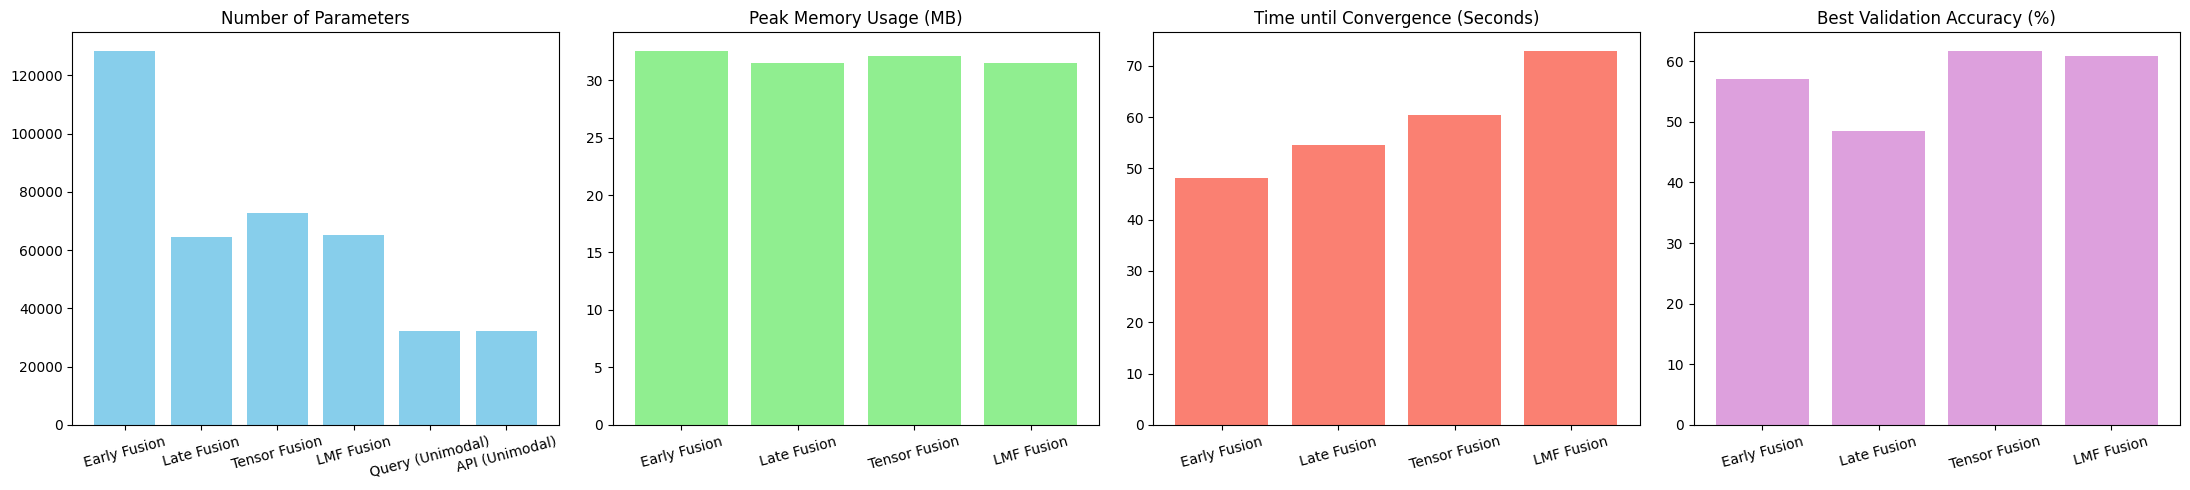

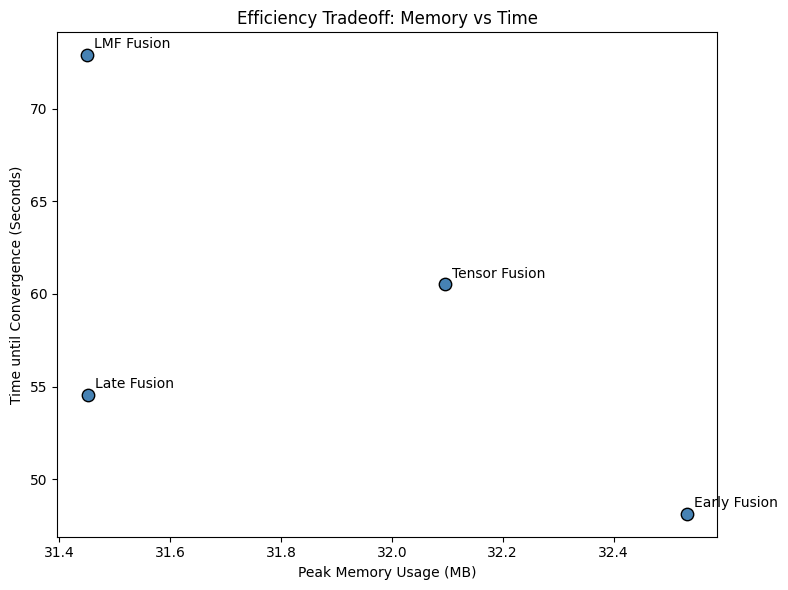

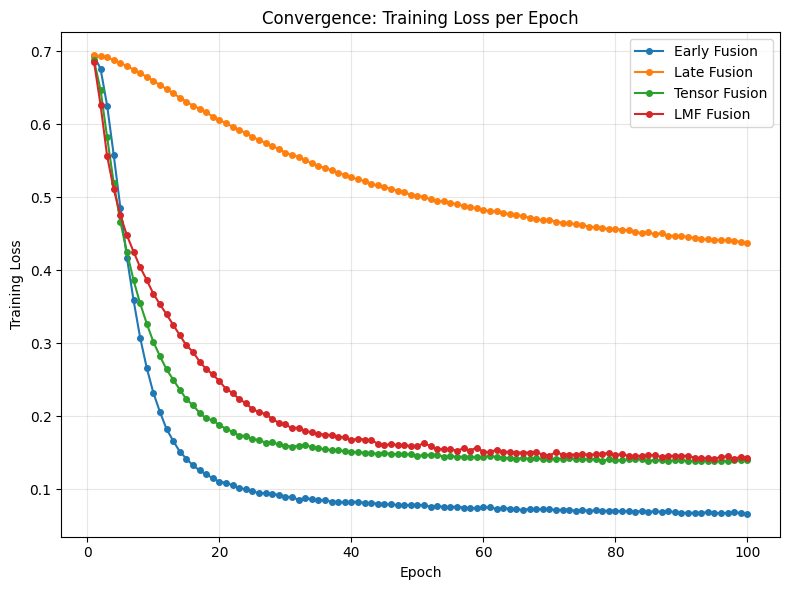

In [25]:
# Run profiling and plot using ToolBench train_loader, val_loader, and dimensions from the cell above.
device = 'cuda' if torch.cuda.is_available() else 'cpu'
metrics = {}
metrics['Early Fusion'] = profile_model_epoch(
    EarlyFusion(TOOLBENCH_QUERY_DIM, TOOLBENCH_API_DIM, TOOLBENCH_NUM_CLASSES), train_loader, val_loader, device)
metrics['Late Fusion'] = profile_model_epoch(
    LateFusion(TOOLBENCH_QUERY_DIM, TOOLBENCH_API_DIM, TOOLBENCH_NUM_CLASSES), train_loader, val_loader, device)
metrics['Tensor Fusion'] = profile_model_epoch(
    TensorFusion(TOOLBENCH_QUERY_DIM, TOOLBENCH_API_DIM, TOOLBENCH_NUM_CLASSES), train_loader, val_loader, device)
metrics['LMF Fusion'] = profile_model_epoch(
    LMFFusion(TOOLBENCH_QUERY_DIM, TOOLBENCH_API_DIM, TOOLBENCH_NUM_CLASSES), train_loader, val_loader, device)

plot_fusion_metrics(metrics)
plot_efficiency_tradeoff(metrics)
plot_convergence_curves(metrics)

In [35]:
# Display metrics at epochs 20, 40, 60, 80, 100 for all 4 models
epochs_to_show = [20, 40, 60, 80, 100]

print("Training loss at selected epochs (and best val accuracy):")
print("=" * 85)
header = f"{'Model':<18} " + "  ".join(f"Epoch {e:>3}" for e in epochs_to_show) + "  Best Val Acc %"
print(header)
print("-" * 85)

for name, m in metrics.items():
    params, memory, total_time, epoch_losses, best_val_acc = m[0], m[1], m[2], m[3], m[4]
    n_epochs = len(epoch_losses)
    values = []
    for e in epochs_to_show:
        if e <= n_epochs:
            values.append(f"{epoch_losses[e - 1]:.4f}")
        else:
            values.append("  —  ")
    row = f"{name:<18} " + "  ".join(f"{v:>8}" for v in values) + f"  {best_val_acc:.2f}"
    print(row)

print("=" * 85)

Training loss at selected epochs (and best val accuracy):
Model              Epoch  20  Epoch  40  Epoch  60  Epoch  80  Epoch 100  Best Val Acc %
-------------------------------------------------------------------------------------
Early Fusion         0.1100    0.0825    0.0749    0.0705    0.0662  57.00
Late Fusion          0.6061    0.5272    0.4827    0.4569    0.4366  48.55
Tensor Fusion        0.1880    0.1510    0.1438    0.1396    0.1400  61.70
LMF Fusion           0.2480    0.1670    0.1512    0.1468    0.1427  60.90


(10 points) In addition, create some visualizations of the following for each fusion:

* Number of parameters for each model (unimodal and multimodal)
* Memory Use
* Time until convergence

You are free to plot them here or through other means (like wandb). After doing so, discuss what are the pros and cons of unimodal versus multimodal models.

# Problem 6: Contrastive Learning (30 points)

For the next part of this HW, we will focus on contrastive learning. As a reminder, contrastive learning is a local, discrete alignment method used in machine learning. To explore this, we look at [CLIP](https://arxiv.org/pdf/2103.00020), a multimodal model developed by OpenAI that uses contrastive learning to align visual and textual data together.

**THIS IS JUST AN EXAMPLE, DO NOT LET THIS RESTRICT THE IMPLEMENTATION YOU WILL BE DOING.**

In [26]:
# torch, clip, PIL, etc. are in the Master Import cell at the top.
import requests
from io import BytesIO

First, we create the model.

In [27]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Loading CLIP on {device}...")
model, preprocess = clip.load("ViT-B/32", device=device)

Loading CLIP on cuda...


100%|████████████████████████████████████████| 338M/338M [00:02<00:00, 121MiB/s]


Next, we will load an image to use. Note that we cannot use the MOSI dataset - we need to use raw data and the data points from the dataset already have extracted features. Upload a picture of someone smiling to use for this example (you can just find one online, save it and add to here).

In [28]:
# Use your own image path, or leave as None to download a sample
image_filename = None  # e.g. "smiling_person.png" or "/content/smiling_person.png"

if image_filename and os.path.isfile(image_filename):
    image = Image.open(image_filename).convert("RGB")
else:
    from io import BytesIO
    import requests
    headers = {"User-Agent": "Mozilla/5.0 (compatible; Python/3; +https://example.com)"}
    sample_urls = [
        "https://upload.wikimedia.org/wikipedia/commons/thumb/4/4e/Macaca_nigra_self-portrait_large.jpg/256px-Macaca_nigra_self-portrait_large.jpg",
        "https://placekitten.com/256/256",
    ]
    image = None
    for url in sample_urls:
        try:
            r = requests.get(url, headers=headers, timeout=10)
            r.raise_for_status()
            image = Image.open(BytesIO(r.content)).convert("RGB")
            break
        except Exception:
            continue
    if image is None:
        raise RuntimeError("Could not load sample image from any URL. Set image_filename to a local image path.")
    print("Using sample image from URL. Set image_filename to your own path to use your image.")

Using sample image from URL. Set image_filename to your own path to use your image.


Now, we will prepare the prompt to use.

In [29]:
# Options to pick from
text_options = ["a photo of a sad person", "a photo of a happy person", "a photo of an angry person"]

# Avoid torchvision's ToTensor (uses numpy) when "Numpy is not available" in Colab
def _pil_to_clip_tensor(pil_img, size=224):
    pil_img = pil_img.resize((size, size), Image.Resampling.LANCZOS)
    b = pil_img.tobytes()
    t = torch.frombuffer(b, dtype=torch.uint8).reshape(size, size, 3).permute(2, 0, 1).float() / 255.0
    mean = torch.tensor([0.48145466, 0.4578275, 0.40821073]).view(3, 1, 1)
    std = torch.tensor([0.26862954, 0.26130258, 0.27577711]).view(3, 1, 1)
    return (t - mean) / std

try:
    image_input = preprocess(image).unsqueeze(0).to(device)
except RuntimeError as e:
    if "Numpy is not available" in str(e):
        image_input = _pil_to_clip_tensor(image).unsqueeze(0).to(device)
    else:
        raise

text_inputs = clip.tokenize(text_options).to(device)

/tmp/ipython-input-3695985956.py:8: UserWarning: The given buffer is not writable, and PyTorch does not support non-writable tensors. This means you can write to the underlying (supposedly non-writable) buffer using the tensor. You may want to copy the buffer to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:1521.)
  t = torch.frombuffer(b, dtype=torch.uint8).reshape(size, size, 3).permute(2, 0, 1).float() / 255.0


Now, let's run the inference and get the results!

In [30]:
with torch.no_grad():
    image_features = model.encode_image(image_input)
    text_features = model.encode_text(text_inputs)

    # Normalize features
    image_features /= image_features.norm(dim=-1, keepdim=True)
    text_features /= text_features.norm(dim=-1, keepdim=True)

    # Calculate similarity (Dot Product)
    similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)
    values, indices = similarity[0].topk(3)

print(f"\nImage classified against: {text_options}")
print("-" * 30)
for value, index in zip(values, indices):
    print(f"{text_options[index]:>30s}: {100 * value.item():.2f}%")


Image classified against: ['a photo of a sad person', 'a photo of a happy person', 'a photo of an angry person']
------------------------------
     a photo of a happy person: 66.99%
    a photo of an angry person: 30.20%
       a photo of a sad person: 2.81%


(10 pts) We will now create, train and run zero-shot classification using contrastive learning for your own dataset. Fill in the missing information below for a generalize contrastive learning model. The training and zero-shot classification functions have been provided to you, through you may need to make slight modifications based on your dataset setup. **Design the model keeping in mind the modalities that you are specifically using. THE CLIP EXAMPLE ABOVE IS JUST TO SHOW CONTRASTIVE LEARNING IN ACTION - WE ARE NOT REQUIRING THAT YOU USE TEXT AND IMAGE AS THE MODALITIES OF CHOICE.** Try various queries, projectors, and settings on your dataset!

**You must use einsum where applicable.**


ToolBench specific alignment:
This is a Query–API cosine similarity (user_query vs function_calls_text in a shared embedding space). I'm going to try this alongside the CLModel above.

In [31]:
class ToolBenchAlignment(nn.Module):
  def __init__(self, dim_query, dim_api, embed_dim, temperature=0.07):
    super().__init__()
    self.temperature = temperature
    self.query_projector = nn.Sequential(
        nn.Linear(dim_query, 128),
        nn.ReLU(),
        nn.Linear(128, embed_dim)
    )
    self.api_projector = nn.Sequential(
        nn.Linear(dim_api, 128),
        nn.ReLU(),
        nn.Linear(128, embed_dim)
    )

  def forward(self, query_feats, api_feats):
    query_emb = self.query_projector(query_feats)
    api_emb = self.api_projector(api_feats)
    query_emb = F.normalize(query_emb, p=2, dim=-1)
    api_emb = F.normalize(api_emb, p=2, dim=-1)
    logits = torch.einsum('id,jd->ij', query_emb, api_emb) / self.temperature
    return logits, query_emb, api_emb


def train_alignment_model(model, dataloader, optimizer, epochs=5, device='cuda'):
  import torch.nn.functional as F
  model.to(device)
  model.train()
  for epoch in range(epochs):
    epoch_loss = 0.0
    num_batches = 0
    for batch in dataloader:
      query_feats, api_feats = batch[0], batch[1]
      query_feats = query_feats.to(device)
      api_feats = api_feats.to(device)
      batch_size = query_feats.size(0)
      logits, query_emb, api_emb = model(query_feats, api_feats)
      labels = torch.arange(batch_size, device=device)
      loss = (F.cross_entropy(logits, labels) + F.cross_entropy(logits.T, labels)) / 2
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()
      epoch_loss += loss.item()
      num_batches += 1
    avg_loss = epoch_loss / num_batches
    print(f"Epoch {epoch + 1}/{epochs}, average loss: {avg_loss:.4f}")

In [32]:
import torch
import seaborn as sns
import matplotlib.pyplot as plt

def visualize_alignment_heatmap(model, query_feats, api_feats, query_texts, api_texts, num_samples=10):
  """
  Plots a heatmap of the cosine similarity between a batch of queries and API calls.
  Takes a subset of the batch (num_samples) for readability.
  """
  model.eval()
  device = next(model.parameters()).device
  with torch.no_grad():
    q_subset = query_feats[:num_samples].to(device)
    a_subset = api_feats[:num_samples].to(device)
    logits, _, _ = model(q_subset, a_subset)
    similarity_matrix = (logits * model.temperature).cpu().tolist()

  plt.figure(figsize=(10, 8))
  sns.heatmap(similarity_matrix, annot=True, cmap="YlGnBu", fmt=".2f",
              xticklabels=[api[:30]+"..." for api in api_texts[:num_samples]],
              yticklabels=[q[:30]+"..." for q in query_texts[:num_samples]])
  plt.title("Query vs API Alignment (Cosine Similarity)")
  plt.xlabel("API Call Schema")
  plt.ylabel("User Query (Natural Language)")
  plt.tight_layout()
  plt.show()

def calculate_recall(similarity_matrix):
  """
  Compute Recall@1 and Recall@5 from a (queries x APIs) similarity matrix.
  For each row i, the true match is column i. Returns average recall as percentages.
  """
  if not isinstance(similarity_matrix, torch.Tensor):
    similarity_matrix = torch.tensor(similarity_matrix, dtype=torch.float32)
  R, C = similarity_matrix.size(0), similarity_matrix.size(1)
  recall_1_hits = 0
  recall_5_hits = 0
  for i in range(R):
    row = similarity_matrix[i]
    k1 = min(1, C)
    k5 = min(5, C)
    _, top1_idx = torch.topk(row, k1)
    _, top5_idx = torch.topk(row, k5)
    if top1_idx[0].item() == i:
      recall_1_hits += 1
    if i in top5_idx.tolist():
      recall_5_hits += 1
  recall_at_1_pct = 100.0 * recall_1_hits / R if R else 0.0
  recall_at_5_pct = 100.0 * recall_5_hits / R if R else 0.0
  return recall_at_1_pct, recall_at_5_pct

def analyze_alignment_success_failure(model, query_feats, api_feats, query_texts, api_texts):
  """
  Identifies successful and failed zero-shot retrievals to answer the written response.
  """
  model.eval()
  device = next(model.parameters()).device
  with torch.no_grad():
    q = query_feats.to(device)
    a = api_feats.to(device)
    logits, _, _ = model(q, a)

  predictions = torch.argmax(logits, dim=1).cpu().tolist()

  print("--- Alignment Analysis: Successes & Failures ---")
  for i, pred_idx in enumerate(predictions):
    success = (i == pred_idx)
    status = "SUCCESS" if success else "FAILED"

    if success and i > 5:
      continue
    if not success and i > 5:
      continue

    print(f"{status}")
    print(f"  User Query: '{query_texts[i]}'")
    print(f"  Expected API: '{api_texts[i]}'")
    if not success:
      print(f"  Predicted API: '{api_texts[pred_idx]}'")
    print("-" * 50)

PRE-TRAINING ALIGNMENT


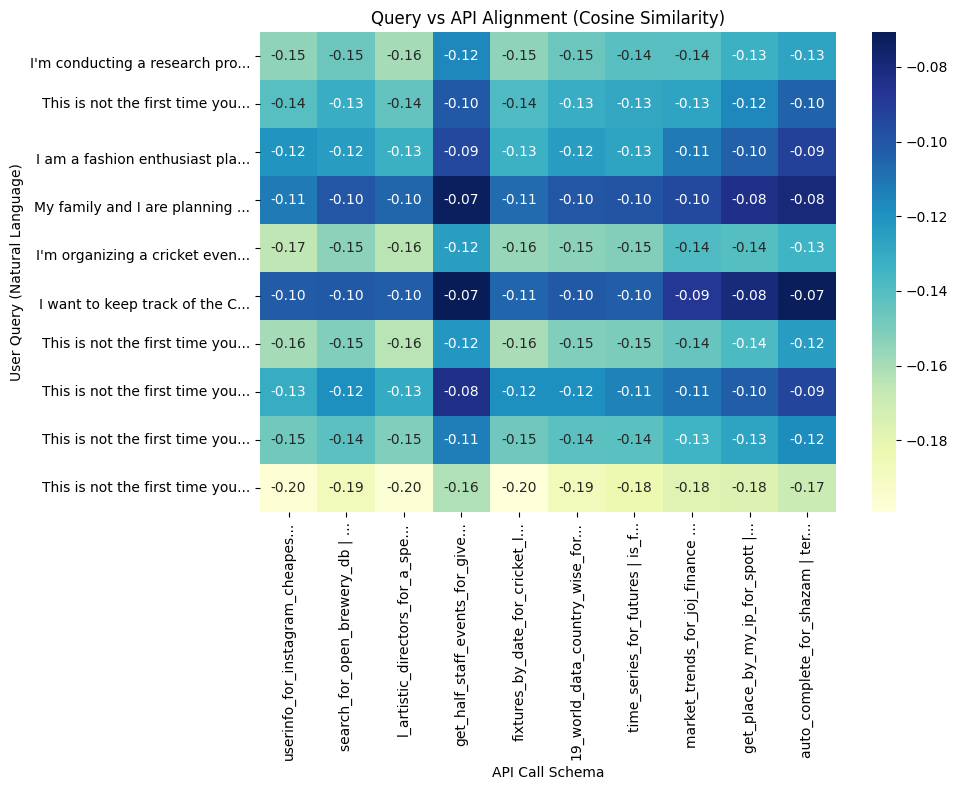

Epoch 1/5, average loss: 3.4131
Epoch 2/5, average loss: 3.1041
Epoch 3/5, average loss: 2.7094
Epoch 4/5, average loss: 2.3121
Epoch 5/5, average loss: 2.0031
POST-TRAINING ALIGNMENT


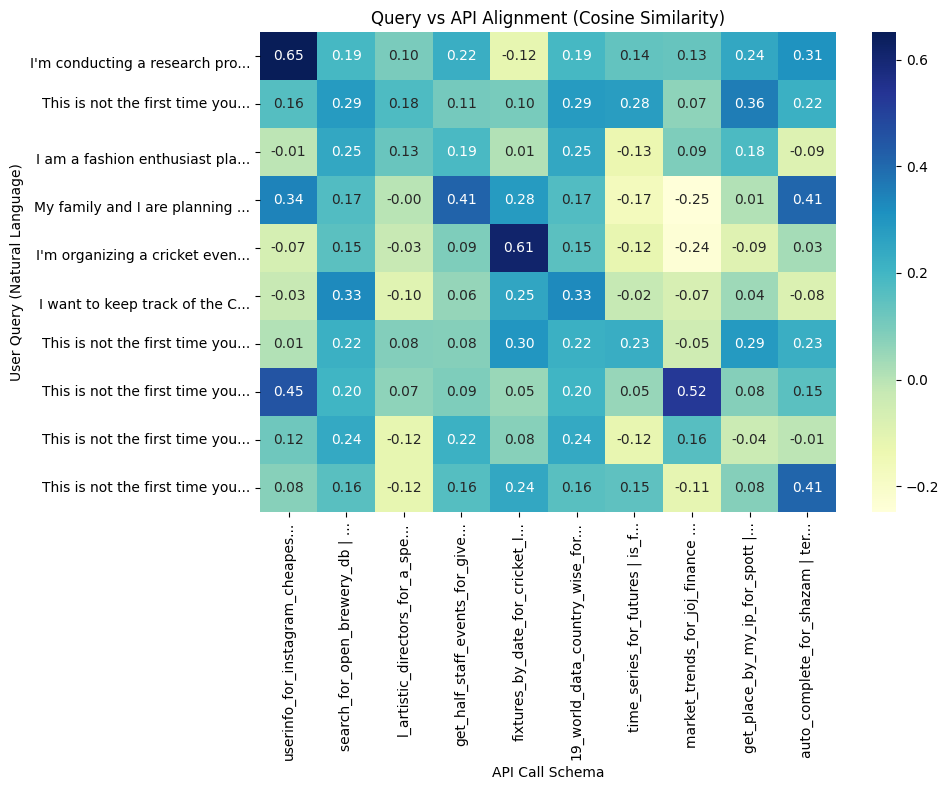

Recall@1: 8.82%
Recall@5: 22.88%
--- Alignment Analysis: Successes & Failures ---
SUCCESS
  User Query: '
I'm conducting a research project on social media influencers, and I'm particularly interested in gathering data from Instagram. Can you help me retrieve user information for a specific username, such as 'nike'? Additionally, I would like to access their recent media posts. Thank you!
Begin!
'
  Expected API: 'userinfo_for_instagram_cheapest | username=nike ;; user_medias_for_instagram_cheapest | user_id=113294420064920 ;; Finish | return_type=give_answer, final_answer=The user 'nike' has a biography of 'Spotlighting athlete* and 🌟 stories
#BlackLivesMatter, #StopAsianHate, and #NoPrideNoSport'. You can find more information about them on their external URL: [https://linkin.bio/nike](https://linkin.bio/nike). Unfortunately, there are no recent media posts available for this user.'
--------------------------------------------------
FAILED
  User Query: 'This is not the first time yo

In [33]:
# Use ToolBench query_feats, api_feats, query_texts, api_texts and dimensions from the data-loading cell.
device = 'cuda' if torch.cuda.is_available() else 'cpu'
embed_dim = 64
alignment_model = ToolBenchAlignment(TOOLBENCH_QUERY_DIM, TOOLBENCH_API_DIM, embed_dim=64).to(device)

print('PRE-TRAINING ALIGNMENT')
visualize_alignment_heatmap(alignment_model, query_feats, api_feats, query_texts, api_texts, num_samples=10)

optimizer = torch.optim.Adam(alignment_model.parameters(), lr=1e-3)
train_alignment_model(alignment_model, train_loader, optimizer, epochs=5, device=device)

print('POST-TRAINING ALIGNMENT')
visualize_alignment_heatmap(alignment_model, query_feats, api_feats, query_texts, api_texts, num_samples=10)
with torch.no_grad():
  device = next(alignment_model.parameters()).device
  logits, _, _ = alignment_model(query_feats.to(device), api_feats.to(device))
  similarity_matrix = logits.cpu()
recall_1, recall_5 = calculate_recall(similarity_matrix)
print(f'Recall@1: {recall_1:.2f}%')
print(f'Recall@5: {recall_5:.2f}%')
analyze_alignment_success_failure(alignment_model, query_feats, api_feats, query_texts, api_texts)

Now answer some of these questions:

1. (5 points) Any suprising results from using this on your dataset?
2. (5 points) Typically, cross-entropy loss is used in this contrastive learning, why is this the case?
3. (10 points) Create some visual examples of the data post alignment. Can you point out samples where the alignment worked and where it failed? Why do you suspect that is?

# Problem 7: Reflection (10 points)

Now we'll take some time to reflect on this homework. Take some time to discuss the following:

1. (5 points) What concept did you find the most interesting?
2. (5 points) Which concepts (if any) do you see being useful towards your goal? Why? If there was none, discuss why.
3. (0 points, optional) Is there a topic that was discussed during lectures up to the release of the assignment that you wished was covered in the homework? Any from the assignment that you wanted there to be touched upon more? Any feedback you have in general for homeworks or the class?